# Model 5 — Evaluation & comparison

Loads every trained model's saved metrics from `artifacts/` and compares them
on the **same** stratified test split, against the mean baseline.

Run this **after** running whichever model notebooks you want to compare.
It reads the `*_metrics.csv` files each notebook writes, so you don't need to
reload the heavy models here.

## Colab setup

Run this cell **first**. It clones the repo (so `kv_common.py` is available),
installs packages, and optionally mounts Google Drive so your cached embeddings
and trained models survive a disconnect.

> For notebook 04 (LoRA), also enable a GPU: **Runtime → Change runtime type → T4 GPU**.

In [1]:
# Clone the repo so kv_common.py and artifacts live in one place.
import os
if not os.path.exists("KVCacheCompression"):
    !git clone -q https://github.com/yoshikodes/KVCacheCompression.git
# Work inside the notebooks folder (edit if your notebooks live elsewhere).
if os.path.basename(os.getcwd()) != "notebooks":
    %cd KVCacheCompression/notebooks
print("cwd:", os.getcwd())
assert os.path.exists("kv_common.py"), "kv_common.py not found"


cwd: /mnt/user-data/outputs/notebooks


In [2]:
# Install packages not preinstalled on Colab.
# If you get an import error right after this, do Runtime -> Restart, then re-run from the top.
!pip install -q scikit-learn scipy requests matplotlib joblib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [3]:
# Optional but recommended: mount Drive so artifacts/ persists across sessions.
# Without this, trained models and cached embeddings are lost on disconnect,
# and notebook 05 will only see models trained in the current session.
USE_DRIVE = True  # set False to keep everything ephemeral

import os
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        ART_DIR = "/content/drive/MyDrive/kv_artifacts"
        os.makedirs(ART_DIR, exist_ok=True)
        # Link ./artifacts -> Drive so all the notebook's save paths persist.
        if os.path.islink("artifacts") or os.path.exists("artifacts"):
            if not os.path.islink("artifacts"):
                import shutil; shutil.rmtree("artifacts", ignore_errors=True)
        if not os.path.exists("artifacts"):
            os.symlink(ART_DIR, "artifacts")
        print("artifacts -> ", os.path.realpath("artifacts"))
    except Exception as e:
        print("Drive mount skipped:", e)
        os.makedirs("artifacts", exist_ok=True)
else:
    os.makedirs("artifacts", exist_ok=True)

Drive mount skipped: No module named 'google.colab'


In [4]:
import numpy as np, pandas as pd, os, glob
import kv_common as kv

df = kv.load_data(verbose=False)
train_df, test_df = kv.stratified_split(df, verbose=False)
y_train = kv.get_targets(train_df); y_test = kv.get_targets(test_df)
baseline = kv.baseline_predict_mean(y_train, len(y_test))
baseline_metrics = kv.evaluate(y_test, baseline)
print("Test rows:", len(test_df))

Test rows: 946


/mnt/user-data/outputs/notebooks/kv_common.py:193: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "Spearman": spearmanr(yt, yp).correlation,
/mnt/user-data/outputs/notebooks/kv_common.py:193: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "Spearman": spearmanr(yt, yp).correlation,
/mnt/user-data/outputs/notebooks/kv_common.py:193: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "Spearman": spearmanr(yt, yp).correlation,
/mnt/user-data/outputs/notebooks/kv_common.py:193: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "Spearman": spearmanr(yt, yp).correlation,
/mnt/user-data/outputs/notebooks/kv_common.py:193: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "Spearman": spearmanr(yt, yp).correlation,
/mnt/user-data/outputs/notebooks/kv_common.py:193:

## Collect metrics from all model notebooks that have been run

In [5]:
files = {
    "baseline_mean": None,   # computed above
    "01_lightgbm":  "artifacts/model1_lightgbm_metrics.csv",
    "02_frozen_emb":"artifacts/model2_frozen_emb_metrics.csv",
    "03_mlp":       "artifacts/model3_mlp_metrics.csv",
    "04_lora":      "artifacts/model4_lora_metrics.csv",
}
rows = []
overall = baseline_metrics[baseline_metrics.setting=="OVERALL"].iloc[0]
rows.append({"model":"baseline_mean","MAE_log":overall.MAE_log,
             "R2_log":overall.R2_log,"Spearman":overall.get("Spearman",np.nan),
             "MAE_raw":overall.get("MAE_raw",np.nan)})
for name, path in files.items():
    if path and os.path.exists(path):
        m = pd.read_csv(path)
        o = m[m.setting=="OVERALL"].iloc[0]
        rows.append({"model":name,"MAE_log":o.MAE_log,"R2_log":o.R2_log,
                     "Spearman":o.get("Spearman",np.nan),
                     "MAE_raw":o.get("MAE_raw",np.nan)})
    elif path:
        print(f"(skipping {name}: {path} not found — run that notebook first)")

summary = pd.DataFrame(rows).sort_values("R2_log", ascending=False).reset_index(drop=True)
print(summary.round(4).to_string(index=False))

(skipping 02_frozen_emb: artifacts/model2_frozen_emb_metrics.csv not found — run that notebook first)
(skipping 03_mlp: artifacts/model3_mlp_metrics.csv not found — run that notebook first)
(skipping 04_lora: artifacts/model4_lora_metrics.csv not found — run that notebook first)
        model  MAE_log  R2_log  Spearman  MAE_raw
  01_lightgbm   0.6713  0.4346    0.7413 417.6567
baseline_mean   1.1154 -0.0003       NaN 409.1702


## Which model wins, per setting
Lower MAE_log is better. Shows where each model is strong.

In [6]:
per_setting = {}
for name, path in files.items():
    if path and os.path.exists(path):
        m = pd.read_csv(path).set_index("setting")["MAE_log"]
        per_setting[name] = m
if per_setting:
    tbl = pd.DataFrame(per_setting)
    tbl = tbl.drop(index="OVERALL", errors="ignore")
    print("Per-setting MAE_log (log space):")
    print(tbl.round(4).to_string())

Per-setting MAE_log (log space):
              01_lightgbm
setting                  
h2o_20             0.8170
h2o_40             0.6551
h2o_60             0.6408
kvquant_2bit       0.6009
kvquant_3bit       0.6665
kvquant_4bit       0.6474


## Bar chart of overall performance

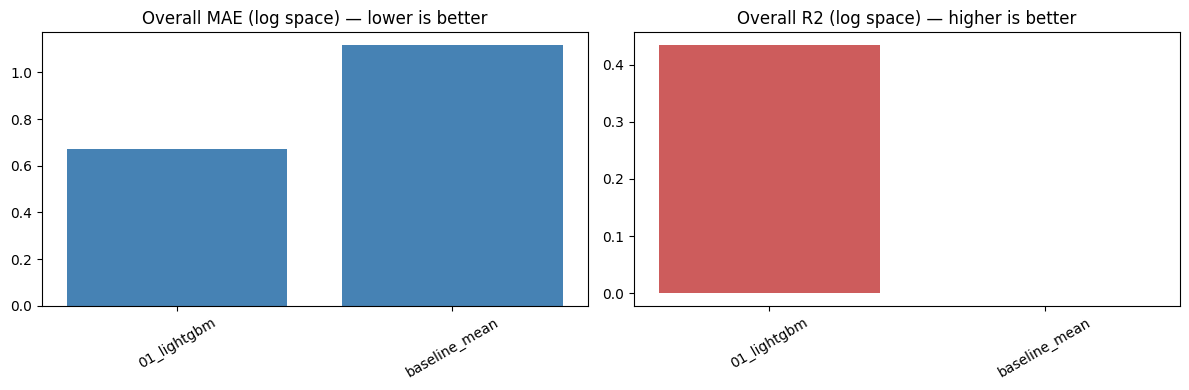

saved artifacts/comparison.png


In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(summary["model"], summary["MAE_log"], color="steelblue")
ax[0].set_title("Overall MAE (log space) — lower is better")
ax[0].tick_params(axis="x", rotation=30)
ax[1].bar(summary["model"], summary["R2_log"], color="indianred")
ax[1].set_title("Overall R2 (log space) — higher is better")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig("artifacts/comparison.png", dpi=120); plt.show()
print("saved artifacts/comparison.png")

## Notes on reading these numbers

- **Beating `baseline_mean`** is the first bar to clear. A model that ties the
  mean has learned nothing useful.
- **R2_log** near 0 = no better than the mean; higher is better. Negative = worse.
- **Spearman** measures ranking quality — useful if you care about *ordering*
  prompts by perplexity rather than exact values.
- **MAE_raw** is in raw perplexity units; it is dominated by the high-perplexity
  datasets (ARC) and the tail, so treat log-space metrics as primary.